# Baryonic Effects on the Nonlinear Matter Power Spectrum

Baryonic processes such as gas cooling, star formation, and feedback from supernovae and active galactic nuclei modify the clustering of matter on small and intermediate scales. These effects redistribute mass within halos and lead to characteristic scale-dependent deviations from a gravity-only prediction of the matter power spectrum.

In this notebook, we compare several **baryonic prescriptions and
emulators** by examining their impact on the nonlinear matter power spectrum
 at redshift $z=0$. All results are shown as ratios

$F(k) = \frac{P_{\mathrm{model}}(k)}{P_{\mathrm{nlin}}(k)}$,

where $P_{\mathrm{nlin}}(k)$ is the same nonlinear reference spectrum in
all cases. This normalization isolates baryonic effects and enables a direct comparison between different modeling approaches, independent of differences in the underlying nonlinear gravity treatment.

The models considered span halo-model–based baryonification schemes, simulation-calibrated correction models, and emulators designed to reproduce hydrodynamical simulation results. The comparison highlights both the scale and magnitude of baryonic modifications predicted by each approach.


More generally, `pyCCL` provides a user-friendly and modular interface for baryonic
corrections, making it straightforward to experiment with different baryon models
and to generate baryon-boosted matter power spectra with minimal changes to the code.
This flexibility enables quick comparisons across modeling approaches and
parameter
choices within a consistent framework.



This notebook serves as an example of how to use the
[baryonic models package](https://ccl.readthedocs.io/en/latest/api/pyccl.baryons.html),
as implemented in `pyCCL`.



## Preliminary Definitions



In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np
import cmasher as cmr
import pyccl as ccl
from pyccl.baryons.fedeli14 import BaryonsFedeli14
print(f"I am using pyCCL version {ccl.__version__}")


I am using pyCCL version 3.2.2.dev12+gba7a7d4ab


We only need three ingredients to explore baryonic models in CCL:
- a cosmology,
- a wavenumber grid,
- and a scale factor.

We compute the gravity-only nonlinear power spectrum here simply as a reference,
so baryonic effects can be shown as a suppression or boost relative to the no-baryons case.

In [2]:
cosmo = ccl.CosmologyVanillaLCDM()  # cosmology object
k_grid = np.logspace(-3, 1, 100)  # wavenumber
a = 1.  # scale factor a z=0
# construct the nonlinear power spectrum with no baryonic effects
pk_nlin = ccl.nonlin_matter_power(cosmo, k_grid, a)

## Power Spectra $P_k$ Computation

### Fedeli et al. (2014) baryonic halo model

[Fedeli et al. (2014)](https://arxiv.org/abs/1407.3404) present a halo-model–based
prescription for baryonic effects, explicitly modeling the redistribution of mass
within halos due to gas and stellar components while preserving large-scale
consistency with a gravity-only prediction.

The baryonic modification is implemented by recomputing the halo-model matter
power spectrum with baryonic halo profiles and taking the ratio with respect to
a dark-matter-only halo-model reference.

To see the detailed implementation in `pyCCL`, call `help(ccl.BaryonsFedeli14)`.


In [3]:
# instantiate the Fedeli+14 baryonic halo-model correction
fed = ccl.baryons.BaryonsFedeli14()

# wrap a baseline nonlinear P(k) with the Fedeli+14 baryonic modification
fed_bary = fed.include_baryonic_effects(
    cosmo=cosmo,
    pk=cosmo.get_nonlin_power(),
)

# evaluate the baryon-corrected P(k,a) on our (k,a) grid
pk_fed = fed_bary(k_grid, a)


### Schneider et al. 2015: Baryon Correction Model

The Baryon Correction Model (BCM) applies baryonic effects as a scale- and redshift-dependent
multiplicative correction to a gravity-only nonlinear matter power spectrum.
We compute the baryon-modified $P(k)$ using the Schneider et al. (2015) prescription
(see [Schneider et al. 2015](https://arxiv.org/abs/1510.06034)).
To see the detailed implementation in `pyCCL`, call `help(ccl.BaryonsSchneider15)`.


In [4]:
# instantiate the BCM (Schneider+15) baryon model
bcm = ccl.baryons.BaryonsSchneider15()

# apply BCM to a baseline nonlinear P(k)
bcm_bary = bcm.include_baryonic_effects(
    cosmo=cosmo,
    pk=cosmo.get_nonlin_power()
)

# evaluate the baryon-corrected P(k,a) on our (k,a) grid
pk_bcm = bcm_bary(k_grid, a)


### Van Daalen et al. (2019) baryonic boost

[Van Daalen et al. (2019)](https://arxiv.org/abs/1906.00968) provide a library of hydrodynamical vs.
collisionless (DMO) matter power spectra from `OWLS`, `cosmo-OWLS`, and
`BAHAMAS`, and an empirical prescription for the baryonic modification of the matter power spectrum.

To see the detailed implementation in `pyCCL`, call `help(ccl.BaryonsVanDaalen19)`.


In [5]:
# instantiate the van Daalen et al. (2019) baryon model
vd = ccl.baryons.BaryonsvanDaalen19()

# apply the van Daalen baryonic correction to a baseline nonlinear P(k)
vd_bary = vd.include_baryonic_effects(
    cosmo=cosmo,
    pk=cosmo.get_nonlin_power()
)

# evaluate the baryon-corrected P(k,a) on our (k,a) grid
pk_vd = vd_bary(k_grid, a)


### Mead et al. (2020): HMCode

HMCode provides a nonlinear matter power spectrum that incorporates baryonic
feedback through an effective halo-model prescription.
We compute the nonlinear $P(k)$ using HMCode as implemented in CAMB
(see [Mead et al. 2020](https://arxiv.org/abs/2009.01858)).
To see the detailed implementation in pyCCL, call `help(ccl.CosmologyVanillaLCDM)`.


In [6]:
# build a ΛCDM cosmology that sources the nonlinear P(k) from CAMB
# (HMCode baryonic feedback is implemented on the CAMB side)
cosmo_hmcode = ccl.CosmologyVanillaLCDM(
    matter_power_spectrum="camb",  # delegate P_nl(k,a) to CAMB
    extra_parameters={
        "camb": {
            "kmax": 20.0,  # CAMB internal k_max (1/Mpc) used for its P(k) tables
            "halofit_version": "mead2020_feedback",  # HMCode / Mead+20 feedback prescription
            "HMCode_logT_AGN": 7.8,  # AGN feedback strength parameter (higher = stronger feedback)
        }
    },
)

# evaluate the HMCode-modified nonlinear matter power spectrum on our (k,a) grid
pk_hmcode = cosmo_hmcode.nonlin_matter_power(k_grid, a)


### Arico et al. (2020): BACCOemu

BACCOemu provides fast, high-accuracy predictions for the nonlinear matter power spectrum using an emulator trained on suites of simulations. It builds on a baryonification approach, where particles in dark-matter-only simulations are displaced to mimic the impact of baryonic feedback, achieving percent-level agreement with hydrodynamical simulations across its validated range (see [Aricò+20](https://arxiv.org/abs/2011.15018)).

Implementation note (CCL): `include_baryonic_effects` is not compatible with
 BACCOemu in our setup because it attempts to apply the correction across
 the full internal $(k, a)$ spline support of the reference `Pk2D`, while BACCOemu is only defined on a more limited $(k, a)$ domain. This range mismatch causes failures/invalid extrapolation, so BACCOemu must be queried directly on the $(k,a)$ grid we use.
 To see the detailed implementation in `pyCCL`, call `help(ccl.BaccoemuBaryons)`.


In [7]:
# instantiate the BACCOemu baryonification-based emulator (Aricò+20)
bacco = ccl.BaccoemuBaryons()

# baseline ΛCDM cosmology used to generate the reference nonlinear P(k)
cosmo_bacco = ccl.CosmologyVanillaLCDM()

# evaluate directly on our (k, a) grid because its valid domain is limited
bacco_boost = bacco.boost_factor(cosmo_bacco, k_grid, a)

# compute the baseline nonlinear matter power spectrum on the same grid
pk_ref = cosmo_bacco.nonlin_matter_power(k_grid, a)

# apply the BACCOemu boost on-grid to obtain the baryon-corrected P(k,a)
pk_bacco = pk_ref * bacco_boost


### Moran et al. (2022): Mira–Titan DMO Emulator

The Mira–Titan emulator provides a high-precision prediction for the dark-matter-only nonlinear matter power spectrum, calibrated on a large suite of N-body simulations.
We start by computing the dark-matter-only (DMO) $P(k)$ from the Mira–Titan
emulator.

For more information about Mira–Titan, see [Heitmann+ 16](https://arxiv.org/abs/1601.00326) and [Moran+ 22](https://arxiv.org/abs/2203.05591). To
see the detailed implementation in pyCCL, call `help(ccl.CosmicemuMTIVPk)`.

In [8]:
# Initialize the Mira–Titan IV emulator (DMO nonlinear P(k) model)
mt = ccl.CosmicemuMTIVPk("tot")

# Build a vanilla ΛCDM cosmology that uses the emulator for the nonlinear power spectrum
cosmo_mt = ccl.CosmologyVanillaLCDM(matter_power_spectrum=mt)

# Evaluate the (DMO) nonlinear matter power spectrum on our k-grid at scale factor a
pk_mt = cosmo_mt.nonlin_matter_power(k_grid, a)


## Plot results

We now compare a set of baryonic prescriptions by plotting the ratio

$F(k)\equiv \frac{P_\mathrm{model}(k)}{P_\mathrm{nlin}(k)}$

as a function of wavenumber.
The gray line at $F(k)=1$ marks the gravity-only nonlinear baseline,
 so departures from unity directly show the scale-dependent suppression or
 enhancement induced by each baryonic model.


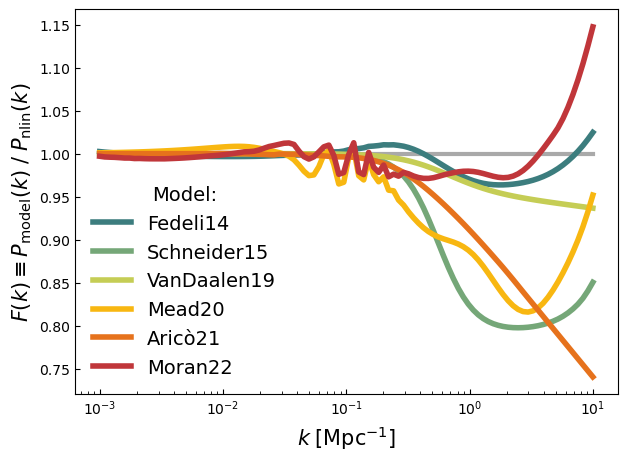

In [9]:
# List of pk data and their labels (first-author surname + year)
# This convention is consistent with ccl naming
pk_data = [
    (pk_fed/pk_nlin, "Fedeli14"),
    (pk_bcm/pk_nlin, "Schneider15"),
    (pk_vd/pk_nlin, "VanDaalen19"),
    (pk_hmcode/pk_nlin, "Mead20"),
    (pk_bacco/pk_nlin, "Aricò21"),
    (pk_mt/pk_nlin, "Moran22"),
]

# take colors from the cmasher colormap
# note: you can also use any matplotlib colormap here
# e.g. pass "viridis" instead of "cmr.pride"
colors = cmr.take_cmap_colors("cmr.pride",
                              len(pk_data),
                              cmap_range=(0.25, 0.75))

plt.figure(figsize=(7, 5))

# reference line for pk_baryons / pk_nonlin = 1
plt.semilogx(k_grid, [1]*len(k_grid), c="darkgray", lw=3)

# loop over the pk data and colors to plot them
for (pk, label), color in zip(pk_data, colors):
    plt.semilogx(k_grid, pk, c=color, label=label, lw=4)

x_label = r"$k \; \mathrm{[Mpc^{-1}]}$"
y_label = r"$F(k)\equiv P_\mathrm{model}(k) \; / \; P_\mathrm{nlin}(k)$"

plt.xlabel(x_label, fontsize=15)
plt.ylabel(y_label, fontsize=15)

plt.gca().tick_params(direction='in', which='both')
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

plt.legend(frameon=False, fontsize=14, ncol=1, loc=3,
           title="Model:", title_fontsize=14)

plt.show()
